# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**:
  * all ETL steps from folder `ELT_feature_extraction`
* **Enviroment**: Jupyter in an Ubuntu VM
* **Machine Learning paradigm:** Supervised learning*
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
* **Models**: Hybrid Models - SeqSleepNet (CNN + BiLSTM + Attention)
* **Files used in this Notebook**: `utils.py`

# Imports

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.signal import medfilt
from tensorflow.keras import layers, models
from keras import ops
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import cohen_kappa_score

In [2]:
import utils

In [3]:
base_path = 'process_dataset/'
train_path = base_path + 'train'
val_path = base_path + 'val'

In [ ]:
def viterbi_decode(proba_seq, transition_matrix):
    T, K = proba_seq.shape
    log_A = np.log(transition_matrix + 1e-12)
    log_B = np.log(proba_seq + 1e-12)

    log_pi = np.log(np.ones(K) / K)

    dp = np.zeros((T, K))
    ptr = np.zeros((T, K), dtype=int)

    dp[0] = log_pi + log_B[0]

    # t >= 1
    for t in range(1, T):
        for k in range(K):
            scores = dp[t - 1] + log_A[:, k]
            ptr[t, k] = np.argmax(scores)
            dp[t, k] = scores[ptr[t, k]] + log_B[t, k]

    best_path = np.zeros(T, dtype=int)
    best_path[-1] = np.argmax(dp[-1])
    for t in range(T - 2, -1, -1):
        best_path[t] = ptr[t + 1, best_path[t + 1]]

    return best_path

# Dataset

In [7]:
df_weights = pd.read_csv(base_path + 'class_distribution_train.csv')
class_weights = dict(zip(df_weights['Class_ID'], df_weights['Weight']))
print("Class weights are:", class_weights)
total_samples = df_weights['Count'].sum()
batch_size = 32
calculated_steps = total_samples // batch_size

print(f"Total number of samples: {total_samples}")
print(f"Steps per train: {calculated_steps}")

Class weights are: {0: 0.944, 1: 1.7783, 2: 0.5232, 3: 1.445, 4: 1.2905}
Total number of samples: 228213
Steps per train: 7131


# Models

## TinySleepNet‑Lite

* experimental model only, not used after this step

In [ ]:
train_gen = utils.SleepDataGenerator(
    train_path,
    batch_size=32,
    is_training=True,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)

val_gen = utils.SleepDataGenerator(
    val_path,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)

y_val_true = []
for i in range(len(val_gen)):
    _, y_batch = val_gen[i]
    y_val_true.extend(np.argmax(y_batch, axis=1))

y_val_true = np.array(y_val_true)

E0000 00:00:1781169396.863150 1009850 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50


I0000 00:00:1781169397.248486 1009850 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.



Epoch 1: val_loss improved from None to 1.92707, saving model to model_tinysleepnet.keras

Epoch 1: finished saving model to model_tinysleepnet.keras
259/259 - 274s - 1s/step - accuracy: 0.4638 - loss: 1.1038 - val_accuracy: 0.1242 - val_loss: 1.9271
Epoch 2/50

Epoch 2: val_loss did not improve from 1.92707
259/259 - 249s - 961ms/step - accuracy: 0.5773 - loss: 0.8466 - val_accuracy: 0.3189 - val_loss: 1.9995
Epoch 3/50

Epoch 3: val_loss improved from 1.92707 to 1.32889, saving model to model_tinysleepnet.keras

Epoch 3: finished saving model to model_tinysleepnet.keras
259/259 - 240s - 928ms/step - accuracy: 0.6143 - loss: 0.7861 - val_accuracy: 0.5148 - val_loss: 1.3289
Epoch 4/50

Epoch 4: val_loss improved from 1.32889 to 1.09415, saving model to model_tinysleepnet.keras

Epoch 4: finished saving model to model_tinysleepnet.keras
259/259 - 237s - 915ms/step - accuracy: 0.6336 - loss: 0.7353 - val_accuracy: 0.5597 - val_loss: 1.0941
Epoch 5/50

Epoch 5: val_loss did not improve f

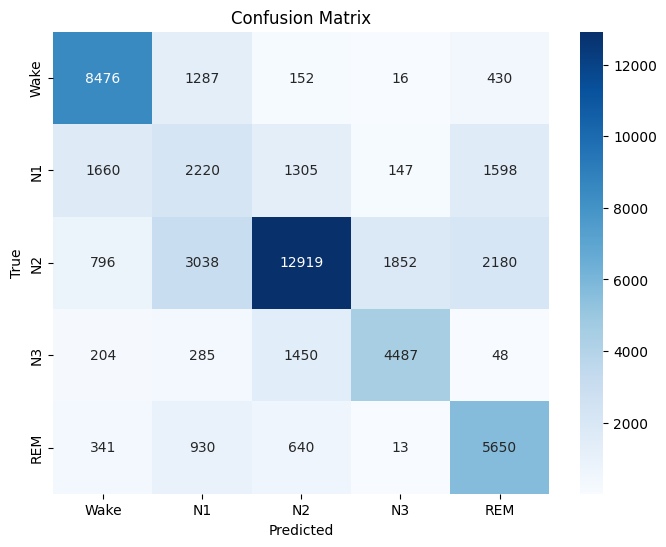

Cohen's Kappa: 0.5407


In [ ]:
def tiny_block(x, filters, kernel_size=11, pool_size=2, dropout=0.2):
    x = layers.SeparableConv1D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=pool_size)(x)
    x = layers.Dropout(dropout)(x)
    return x

def temporal_attention(x):
    score = layers.Dense(1)(x)
    weights = layers.Softmax(axis=1)(score)
    context = ops.sum(x * weights, axis=1)
    return context

num_classes = 5

inputs = layers.Input(shape=(3000, 2))

x = tiny_block(inputs, 32, kernel_size=11, pool_size=2, dropout=0.1)   # 4500 -> 2250
x = tiny_block(x, 64, kernel_size=11, pool_size=2, dropout=0.1)   # 2250 -> 1125
x = tiny_block(x,     128, kernel_size=11, pool_size=2, dropout=0.1)   # 1125 -> 562
x = tiny_block(x,     128, kernel_size=11, pool_size=2, dropout=0.1)   # 562 -> 281

x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
x = layers.Dropout(0.3)(x)

x = temporal_attention(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_tiny = models.Model(inputs, outputs)

alpha = [1.0, 3.0, 1.0, 1.2, 2.5]

model_tiny.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=utils.categorical_focal_loss(gamma=2.0, alpha=alpha),
    metrics=["accuracy"]
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history = model_tiny.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[es],
    verbose=2
)

y_pred_proba = model_tiny.predict(val_gen)
y_val_pred = np.argmax(y_pred_proba, axis=1)

acc, kappa = utils.evaluate_model(y_val_true, y_val_pred)

### Median Filter Smoothing

56/56 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step
Accuracy 0.6634

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.77      0.80      0.78     10361
          N1       0.29      0.33      0.31      6930
          N2       0.76      0.66      0.71     20785
          N3       0.70      0.69      0.69      6474
         REM       0.64      0.77      0.70      7574

    accuracy                           0.66     52124
   macro avg       0.63      0.65      0.64     52124
weighted avg       0.68      0.66      0.67     52124



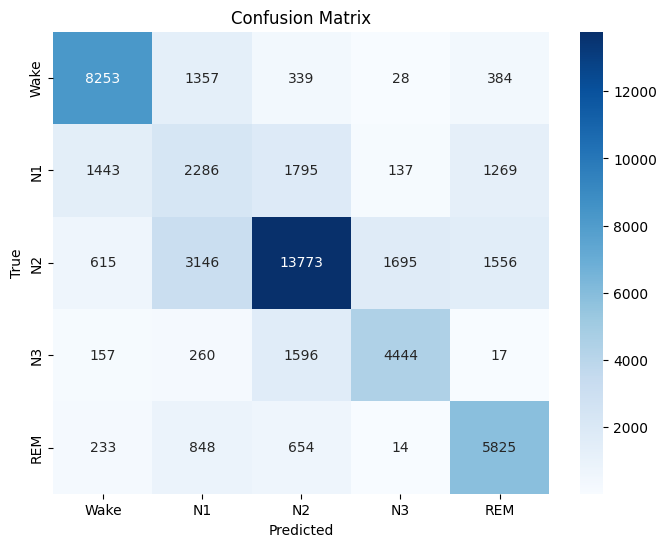

Cohen's Kappa: 0.5571


In [10]:
y_pred_proba = model_tiny.predict(val_gen)
y_pred = np.argmax(y_pred_proba, axis=1)

y_pred_smooth = medfilt(y_pred, kernel_size=5)
acc, kappa = utils.evaluate_model(y_val_true, y_pred_smooth)

In [ ]:
train_gen = utils.SleepDataGenerator(
    train_path,
    batch_size=32,
    is_training=True,
    use_context=True,
    window_size=3,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    select_channels=[0]
)

val_gen = utils.SleepDataGenerator(
    val_path,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    select_channels=[0]
)

y_val_true = []
for i in range(len(val_gen)):
    _, y_batch = val_gen[i]
    y_val_true.extend(np.argmax(y_batch, axis=1))
y_val_true = np.array(y_val_true)

def categorical_focal_loss(gamma=2.0, alpha=None):
    def loss(y_true, y_pred):
        y_pred = ops.clip(y_pred, 1e-7, 1.0)
        ce = -ops.sum(y_true * ops.log(y_pred), axis=-1)
        p_t = ops.sum(y_true * y_pred, axis=-1)
        modulating = (1.0 - p_t) ** gamma

        if alpha is not None:
            alpha_t = ops.sum(y_true * ops.convert_to_tensor(alpha), axis=-1)
            fl = alpha_t * modulating * ce
        else:
            fl = modulating * ce

        return ops.mean(fl)
    return loss

alpha = [1.0, 3.0, 1.0, 1.2, 2.5]  # Wake, N1, N2, N3, REM

Epoch 1/50

Epoch 1: val_loss improved from None to 9.69409, saving model to tinysleepnet_real.keras

Epoch 1: finished saving model to tinysleepnet_real.keras
259/259 - 211s - 816ms/step - accuracy: 0.2443 - loss: 1.6917 - val_accuracy: 0.1980 - val_loss: 9.6941 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss did not improve from 9.69409
259/259 - 209s - 805ms/step - accuracy: 0.3618 - loss: 1.4162 - val_accuracy: 0.2287 - val_loss: 11.2654 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss improved from 9.69409 to 1.94579, saving model to tinysleepnet_real.keras

Epoch 3: finished saving model to tinysleepnet_real.keras
259/259 - 204s - 787ms/step - accuracy: 0.3808 - loss: 1.3797 - val_accuracy: 0.3262 - val_loss: 1.9458 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_loss improved from 1.94579 to 1.85012, saving model to tinysleepnet_real.keras

Epoch 4: finished saving model to tinysleepnet_real.keras
259/259 - 201s - 775ms/step - accuracy: 0.3797 - loss: 1.3838 - val_ac

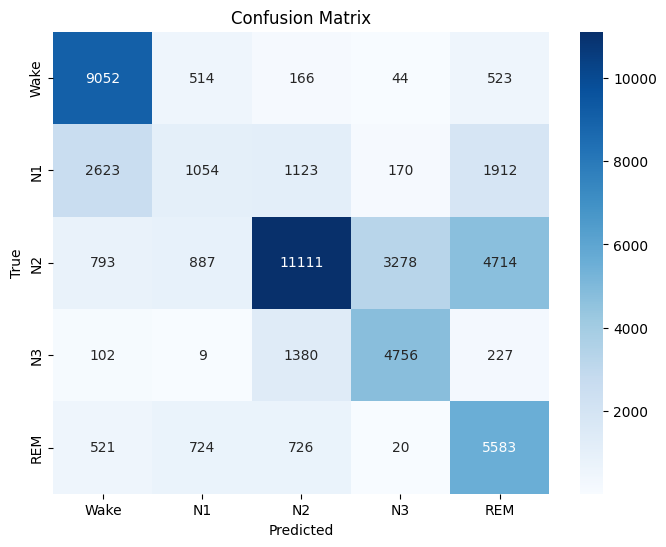

Cohen's Kappa: 0.4922


In [ ]:
def tiny_block(x, filters, kernel_size=11, pool_size=2, dropout=0.25):
    x = layers.SeparableConv1D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size)(x)
    x = layers.Dropout(dropout)(x)
    return x

inputs = layers.Input(shape=(4500, 1), name="input_eeg")

x = tiny_block(inputs, 32, 11, 2, 0.2)
x = tiny_block(x, 64, 11, 2, 0.2)
x = tiny_block(x, 128, 11, 2, 0.2)
x = tiny_block(x, 128, 11, 2, 0.2)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation="softmax")(x)

model_tiny_real = models.Model(inputs, outputs)

alpha = [1.0, 3.0, 1.0, 1.2, 2.5]

model_tiny_real.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

ckpt = tf.keras.callbacks.ModelCheckpoint(
    "tinysleepnet_real.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_tiny = model_tiny_real.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[lr_scheduler, es, ckpt],
    verbose=2
)

y_pred_proba_tiny = model_tiny_real.predict(val_gen)
y_pred_tiny = np.argmax(y_pred_proba_tiny, axis=1)

acc_tiny, kappa_tiny = utils.evaluate_model(y_val_true, y_pred_tiny)

Accuracy 0.6098

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.65      0.90      0.76     10299
          N1       0.50      0.03      0.06      6882
          N2       0.76      0.53      0.63     20783
          N3       0.57      0.73      0.64      6474
         REM       0.44      0.85      0.58      7574

    accuracy                           0.61     52012
   macro avg       0.58      0.61      0.53     52012
weighted avg       0.63      0.61      0.57     52012



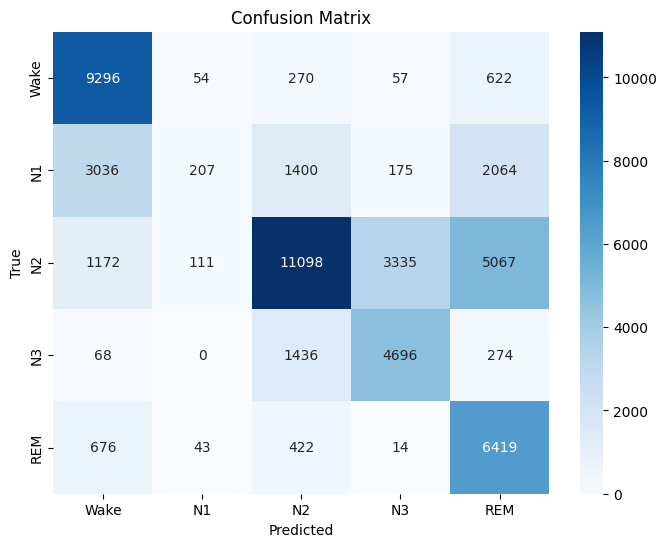

Cohen's Kappa: 0.4946


In [ ]:
proba_smooth = gaussian_filter1d(y_pred_proba_tiny, sigma=1.0, axis=0)
y_pred_hmm = viterbi_decode(proba_smooth, A)

acc_tiny, kappa_tiny = utils.evaluate_model(y_val_true, y_pred_hmm)

## SeqSleepNet

In [ ]:
train_gen = utils.SleepDataGenerator(
    train_path,
    batch_size=32,
    is_training=True,
    use_context=True,
    window_size=3,
    use_lag_lead=False,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5,
    select_channels=[0]
)

val_gen = utils.SleepDataGenerator(
    val_path,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=False,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5,
    select_channels=[0]
)

y_val_true = []
for i in range(len(val_gen)):
    _, y_batch = val_gen[i]
    y_val_true.extend(np.argmax(y_batch, axis=1))

y_val_true = np.array(y_val_true)
num_classes = 5

Epoch 1/50

Epoch 1: val_loss improved from None to 1.49954, saving model to seqsleepnet.keras

Epoch 1: finished saving model to seqsleepnet.keras
259/259 - 1940s - 7s/step - accuracy: 0.2358 - loss: 1.5597 - val_accuracy: 0.3193 - val_loss: 1.4995 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 1.49954 to 1.30110, saving model to seqsleepnet.keras

Epoch 2: finished saving model to seqsleepnet.keras
259/259 - 1384s - 5s/step - accuracy: 0.3500 - loss: 1.3977 - val_accuracy: 0.4554 - val_loss: 1.3011 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss did not improve from 1.30110
259/259 - 1378s - 5s/step - accuracy: 0.4445 - loss: 1.2984 - val_accuracy: 0.4046 - val_loss: 1.3410 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_loss improved from 1.30110 to 1.29731, saving model to seqsleepnet.keras

Epoch 4: finished saving model to seqsleepnet.keras
259/259 - 1381s - 5s/step - accuracy: 0.4595 - loss: 1.2743 - val_accuracy: 0.4121 - val_loss: 1.2973 - learning_

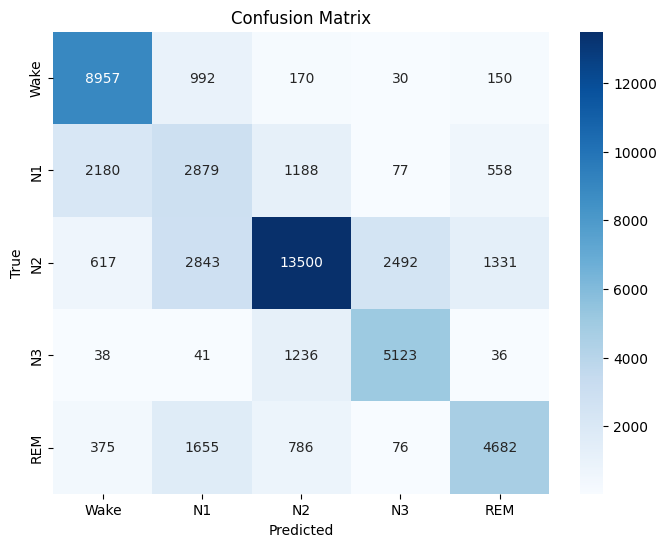

Cohen's Kappa: 0.5760


In [ ]:
def frame_encoder(frame_input, frame_units=64):
    x = layers.Bidirectional(layers.GRU(frame_units, return_sequences=True))(frame_input)
    x = layers.Bidirectional(layers.GRU(frame_units))(x)
    return x

# class Attention(layers.Layer):
#     def __init__(self, units):
#         super().__init__()
#         self.W = layers.Dense(units)
#         self.V = layers.Dense(1)

#     def call(self, inputs):
#         score = self.V(tf.nn.tanh(self.W(inputs)))
#         weights = tf.nn.softmax(score, axis=1)
#         context = tf.reduce_sum(weights * inputs, axis=1)
#         return context

def build_seqsleepnet(input_length=4500, frame_length=50, frame_units=64, epoch_units=128):
    num_frames = input_length // frame_length

    inputs = layers.Input(shape=(input_length, 1))

    # Reshape into frames
    x = layers.Reshape((num_frames, frame_length, 1))(inputs)

    # Frame-level encoding
    x = layers.TimeDistributed(layers.Bidirectional(layers.GRU(frame_units, return_sequences=True)))(x)
    x = layers.TimeDistributed(layers.Bidirectional(layers.GRU(frame_units)))(x)

    # Epoch-level encoding
    x = layers.Bidirectional(layers.GRU(epoch_units, return_sequences=True))(x)

    # Attention
    x = utils.Attention(epoch_units)(x)

    # Classifier
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs)

model_seq = build_seqsleepnet()

model_seq.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_seq = model_seq.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[es, lr_scheduler],
    verbose=2
)

y_pred_proba = model_seq.predict(val_gen)
y_pred = np.argmax(y_pred_proba, axis=1)

acc, kappa = utils.evaluate_model(y_val_true, y_pred)

### Grid Search

In [ ]:
num_classes = 5

# 1. Smoothing sets
sigma_sets = [
    [1.0],                 # simple
    [0.5, 1.0, 1.5],       # ensemble
]

def apply_smoothing(proba, sigmas):
    smoothed = [gaussian_filter1d(proba, sigma=s, axis=0, mode="nearest") for s in sigmas]
    return np.mean(smoothed, axis=0)

# 2. HMM temperature sets
temperature_sets = [
    [0.85, 0.45, 0.75, 0.95, 0.75],
    [0.80, 0.50, 0.70, 0.90, 0.70],
]

def compute_A(y, temps):
    A = np.ones((num_classes, num_classes)) * 1e-3
    for i in range(len(y) - 1):
        A[y[i], y[i+1]] += 1
    A = A / A.sum(axis=1, keepdims=True)
    for c in range(num_classes):
        A[c] = A[c] ** temps[c]
        A[c] = A[c] / A[c].sum()
    return A

# 3. Viterbi
def viterbi(proba, A):
    T, C = proba.shape
    logA = np.log(A + 1e-12)
    logP = np.log(np.clip(proba, 1e-8, 1.0))

    delta = np.zeros((T, C))
    psi = np.zeros((T, C), dtype=int)

    delta[0] = logP[0]

    for t in range(1, T):
        scores = delta[t-1][:, None] + logA
        psi[t] = np.argmax(scores, axis=0)
        delta[t] = np.max(scores, axis=0) + logP[t]

    states = np.zeros(T, dtype=int)
    states[-1] = np.argmax(delta[-1])
    for t in range(T - 2, -1, -1):
        states[t] = psi[t+1, states[t+1]]

    return states

# 4. Median filter sets 
median_sets = [
    {0:5, 1:3, 2:5, 3:9, 4:5},
    {0:5, 1:5, 2:7, 3:9, 4:5},
]

def safe_medfilt(seq, center, k):
    half = k // 2
    start = max(0, center - half)
    end = min(len(seq), center + half + 1)
    window = seq[start:end]
    if len(window) < k:
        k = len(window) if len(window) % 2 == 1 else len(window) - 1
        if k < 1:
            return seq[center]
    return medfilt(window, kernel_size=k)[len(window)//2]

def adaptive_median(seq, kernels):
    out = seq.copy()
    for i in range(len(seq)):
        out[i] = safe_medfilt(seq, i, kernels[seq[i]])
    return out

# 5. Physiologic rule sets (2 variante)
def rules_v1(seq):
    out = seq.copy()
    for i in range(1, len(seq)-1):
        prev, cur, nxt = seq[i-1], seq[i], seq[i+1]
        if prev == 1 and cur == 3 and nxt == 1:
            out[i] = 2
        if prev == 4 and cur == 2 and nxt == 4:
            out[i] = 4
    return out

def rules_v2(seq):
    out = seq.copy()
    for i in range(1, len(seq)-1):
        prev, cur, nxt = seq[i-1], seq[i], seq[i+1]
        if prev == 1 and cur == 3 and nxt == 1:
            out[i] = 2
        if prev == 4 and cur == 2 and nxt == 4:
            out[i] = 4
        if prev == 3 and cur == 0 and nxt == 3:
            out[i] = 2
    return out

rule_sets = [rules_v1, rules_v2]

# 6. Ensemble alpha
alphas = [0.7, 1.0]

def ensemble(hmm, smooth, alpha):
    return np.clip(np.round(alpha * hmm + (1 - alpha) * smooth).astype(int), 0, num_classes - 1)


In [37]:
best_acc = -1
best_combo = None
best_pred = None

for sigmas in sigma_sets:
    proba_s = apply_smoothing(y_pred_proba, sigmas)
    y_smooth = np.argmax(proba_s, axis=1)

    for temps in temperature_sets:
        A = compute_A(y_val_true, temps)
        y_hmm = viterbi(proba_s, A)

        for kernels in median_sets:
            y_med = adaptive_median(y_hmm, kernels)

            for rules in rule_sets:
                y_rules = rules(y_med)

                for alpha in alphas:
                    y_final = ensemble(y_rules, y_smooth, alpha)

                    acc = np.mean(y_final == y_val_true)
                    kappa = cohen_kappa_score(y_val_true, y_final)

                    print(f"sigmas={sigmas}, temps={temps}, kernels={kernels}, rules={rules.__name__}, alpha={alpha} \nacc={acc:.4f}, kappa={kappa:.4f}\n")

                    if acc > best_acc:
                        best_acc = acc
                        best_combo = (sigmas, temps, kernels, rules.__name__, alpha)
                        best_pred = y_final

print("\n=== BEST COMBINATION ===")
print("Accuracy:", best_acc)
print("Best params:", best_combo)

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 3, 2: 5, 3: 9, 4: 5}, rules=rules_v2, alpha=0.7 
acc=0.6801, kappa=0.5744

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 3, 2: 5, 3: 9, 4: 5}, rules=rules_v2, alpha=1.0 
acc=0.7051, kappa=0.6062

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 3, 2: 5, 3: 9, 4: 5}, rules=rules_v3, alpha=0.7 
acc=0.6801, kappa=0.5744

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 3, 2: 5, 3: 9, 4: 5}, rules=rules_v3, alpha=1.0 
acc=0.7051, kappa=0.6062

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 5, 2: 7, 3: 9, 4: 5}, rules=rules_v2, alpha=0.7 
acc=0.6802, kappa=0.5744

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 5, 2: 7, 3: 9, 4: 5}, rules=rules_v2, alpha=1.0 
acc=0.7052, kappa=0.6062

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 5, 2: 7, 3: 9, 4: 5}, rules=rules_v3, alpha=0.7 
acc=0.6802,

### Best Result

Accuracy 0.7056

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.68      0.90      0.78     10299
          N1       0.42      0.16      0.23      6882
          N2       0.78      0.73      0.75     20783
          N3       0.66      0.80      0.72      6474
         REM       0.71      0.78      0.74      7574

    accuracy                           0.71     52012
   macro avg       0.65      0.67      0.65     52012
weighted avg       0.69      0.71      0.68     52012



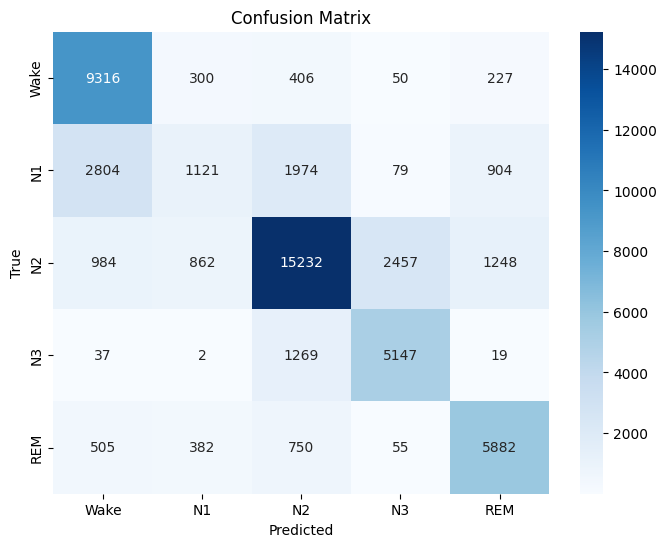

Cohen's Kappa: 0.6067


In [ ]:
num_classes = 5
CLASSES = ["Wake", "N1", "N2", "N3", "REM"]
sigma_list = [0.5, 1.0, 1.5]

probas_smooth = [
    gaussian_filter1d(y_pred_proba, sigma=s, axis=0, mode="nearest")
    for s in sigma_list
]

proba_smooth = np.mean(probas_smooth, axis=0)
y_pred_smooth = np.argmax(proba_smooth, axis=1)

temps = [0.85, 0.45, 0.75, 0.95, 0.75]
A = utils.compute_transition_matrix_adaptive(y_val_true, temps)
y_hmm = utils.viterbi(proba_smooth, A)
y_med = utils.adaptive_median(y_hmm)
y_final = utils.physiologic_rules(y_med)

acc, kappa = utils.evaluate_model(y_val_true, y_final)